In [1]:
%matplotlib inline


# Fitting an image and points

In this example, we will fit a cross onto the same cross, but rotated. We will take advantage of this knowledge and use a rotation deformation module. We will also add some noise on the initial center guess to show how to fit the geometrical descriptors. In addition to images, we add points at the extremity of each branch that will also get matched in order to illustrate multi deformables matching. This also helps the fitting process by adding more information to the model.




Import relevant modules.




In [2]:
import sys
sys.path.append("../")

import math

import torch
import matplotlib.pyplot as plt
import scipy.ndimage

import imodal

imodal.Utilities.set_compute_backend('torch')

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


Load image data and generate dots.




In [3]:
source_image = imodal.Utilities.load_greyscale_image("../data/cross_source.png", origin='lower')
target_image = imodal.Utilities.load_greyscale_image("../data/cross_target.png", origin='lower')

# Smoothing

extent_length = 31.
extent = imodal.Utilities.AABB(0., extent_length, 0., extent_length)

dots = torch.tensor([[0., 0.5],
                     [0.5, 0.],
                     [0., -0.5],
                     [-0.5, 0.]])

source_dots = 0.6*extent_length*imodal.Utilities.linear_transform(dots, imodal.Utilities.rot2d(math.pi/3)) + extent_length*torch.tensor([0.5, 0.5])

target_dots = 0.6*extent_length*imodal.Utilities.linear_transform(dots, imodal.Utilities.rot2d(math.pi/1)) + extent_length*torch.tensor([0.5, 0.5])

center = extent_length*torch.tensor([[0.3, 0.1]])

Plot everything.




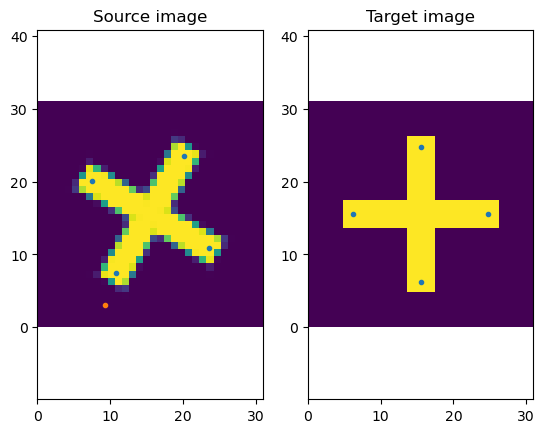

In [4]:
plt.subplot(1, 2, 1)
plt.title("Source image")
plt.imshow(source_image, origin='lower', extent=extent.totuple())
plt.plot(source_dots.numpy()[:, 0], source_dots.numpy()[:, 1], '.')
plt.plot(center.numpy()[:, 0], center.numpy()[:, 1], '.')
plt.axis('equal')
plt.subplot(1, 2, 2)
plt.title("Target image")
plt.imshow(target_image, origin='lower', extent=extent.totuple())
plt.plot(target_dots.numpy()[:, 0], target_dots.numpy()[:, 1], '.')
plt.axis('equal')

plt.show()

We know that the target cross is the result of some rotation at its origin,
so we use a local rotation deformation module, with an imprecise center
position to simulate data aquisition noise.




In [5]:
rotation = imodal.DeformationModules.LocalRotation(2, 2.*extent_length, gd=center)

Create the model by setting `True` for `fit_gd` so that it also optimize the
rotation center.




In [9]:
source_deformable = imodal.Models.DeformableImage(source_image, output='bitmap', extent='match', backward=False)
target_deformable = imodal.Models.DeformableImage(target_image, output='bitmap', extent='match', backward=False)

source_dots_deformable = imodal.Models.DeformablePoints(source_dots)
target_dots_deformable = imodal.Models.DeformablePoints(target_dots)

attachment = imodal.Attachment.L2NormAttachment(transform=None)

model = imodal.Models.RegistrationModel([source_dots_deformable, source_deformable], [rotation], [imodal.Attachment.EuclideanPointwiseDistanceAttachment(), attachment], fit_gd=[True], lam=200.)


Fit the model.




In [10]:
shoot_solver = 'rk4'
shoot_it = 10
max_it = 100

costs = {}
fitter = imodal.Models.Fitter(model, optimizer='torch_lbfgs')

fitter.fit([target_dots_deformable, target_deformable], max_it, costs=costs, options={'shoot_solver': shoot_solver, 'shoot_it': shoot_it, 'line_search_fn': 'strong_wolfe'})


Starting optimization with method torch LBFGS, using solver rk4 with 10 iterations.
Initial cost={'deformation': 0.0, 'attach': 52551.1640625}
1e-10
Evaluated model with costs=52551.1640625
Evaluated model with costs=52214.72529935837
Evaluated model with costs=52052.895551770926
Evaluated model with costs=48892.19981765747
Evaluated model with costs=41378.4189453125
Evaluated model with costs=42116.09619140625
Evaluated model with costs=40677.87841796875
Evaluated model with costs=40663.510009765625
Evaluated model with costs=40608.769775390625
Evaluated model with costs=40089.46337890625
Evaluated model with costs=38674.052978515625
Evaluated model with costs=34066.697509765625
Evaluated model with costs=33884.07666015625
Evaluated model with costs=48067.42868804932
Evaluated model with costs=33903.71044921875
Evaluated model with costs=33863.412109375
Evaluated model with costs=32629.267578125
Evaluated model with costs=29757.73681640625
Evaluated model with costs=27040.357421875
Ev

{'c1': [], 'c2': [], 'c3': []}

Plot total cost evolution.




Compute the final deformed source and plot it.




Fitted rotatation center: [[15.488452911376953, 15.47286605834961]]


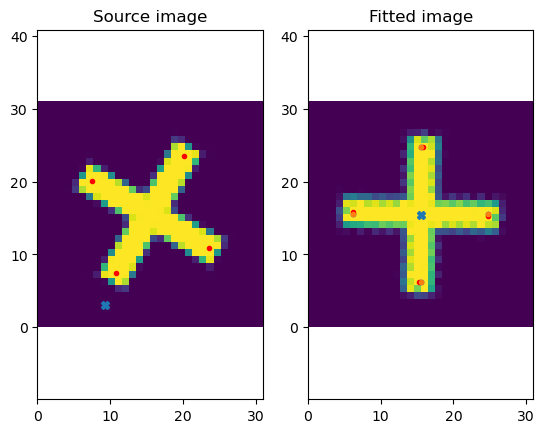

In [18]:
with torch.autograd.no_grad():
    model.deformables[0].output = 'bitmap'
    deformed = model.compute_deformed(shoot_solver, shoot_it)

    deformed_image = deformed[1][0].view_as(source_image)
    deformed_dots = deformed[0][0]

fitted_center = model.init_manifold[2].gd.detach()

print("Fitted rotatation center: {center}".format(center=fitted_center.detach().tolist()))

plt.subplot(1, 2, 1)
plt.title("Source image")
plt.imshow(source_image.numpy(), origin='lower', extent=extent.totuple())
plt.plot(source_dots.numpy()[:, 0], source_dots.numpy()[:, 1], '.r')
#plt.plot(target_dots.numpy()[:, 0], target_dots.numpy()[:, 1], '.b')
plt.plot(center.numpy()[0, 0], center.numpy()[0, 1], 'X')
plt.axis('equal')
#plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Fitted image")
plt.imshow(deformed_image.numpy(), origin='lower', extent=extent.totuple())
#plt.plot(source_dots.numpy()[:, 0], source_dots.numpy()[:, 1], 'g')
plt.plot(target_dots.numpy()[:, 0], target_dots.numpy()[:, 1], '.b')
plt.plot(deformed_dots.numpy()[:, 0], deformed_dots.numpy()[:, 1], '.r')
plt.plot(fitted_center.numpy()[0, 0], fitted_center.numpy()[0, 1], 'X')
plt.plot(target_dots.numpy()[:, 0], target_dots.numpy()[:, 1], '.')
plt.axis('equal')
#plt.axis('off')

plt.show()

In [20]:
with torch.autograd.no_grad():
    intermediates = {}
    model.deformables[0].output = 'bitmap'
    deformed = model.compute_deformed(shoot_solver, shoot_it, intermediates=intermediates)

    deformed_image = deformed[1][0].view_as(source_image)
    deformed_dots = deformed[0][0]


In [31]:
intermediates['states'][0].manifolds[2].nb_pts

1

In [40]:
i = 10
deformed_image_i = source_deformable._to_deformed(
                intermediates['states'][i].manifolds[1].gd)

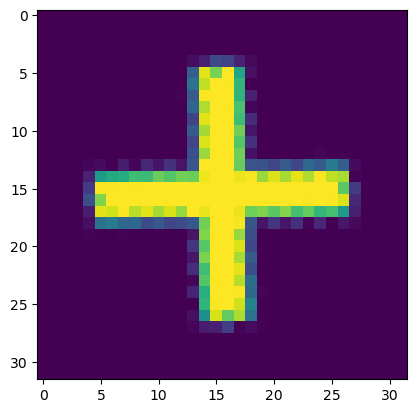

In [41]:
plt.imshow(deformed_image_i[0])

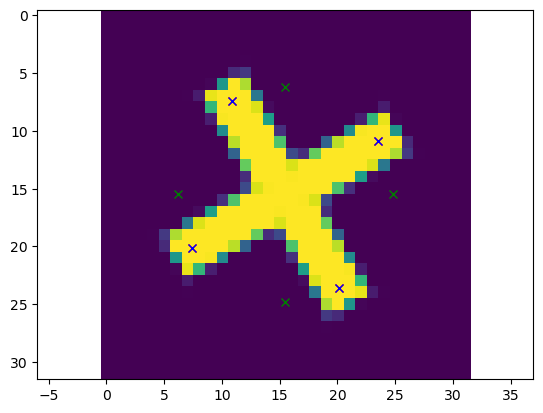

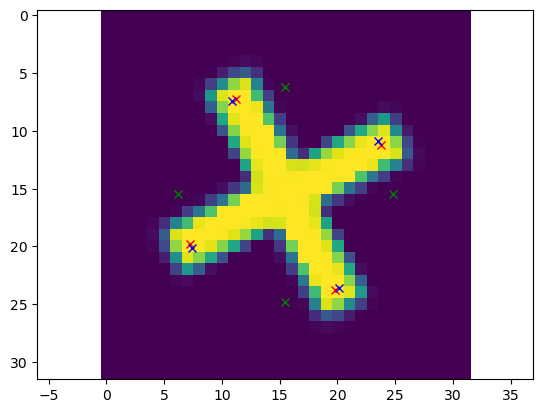

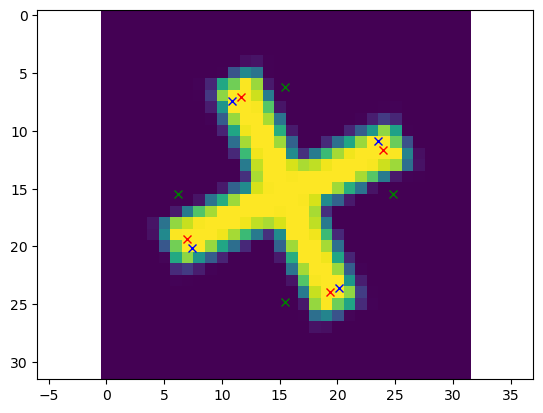

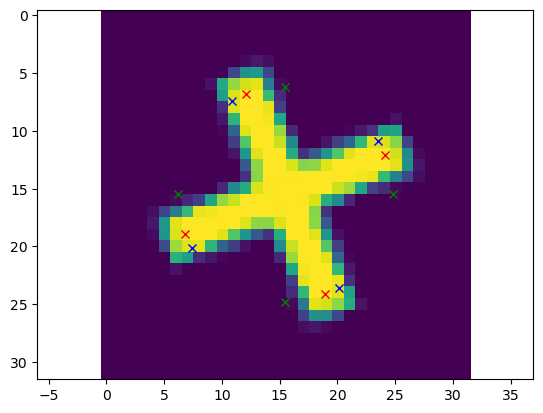

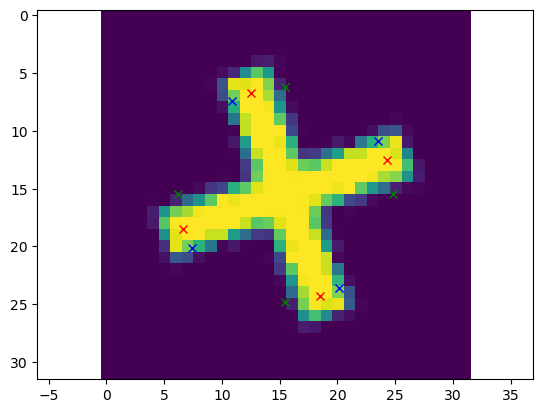

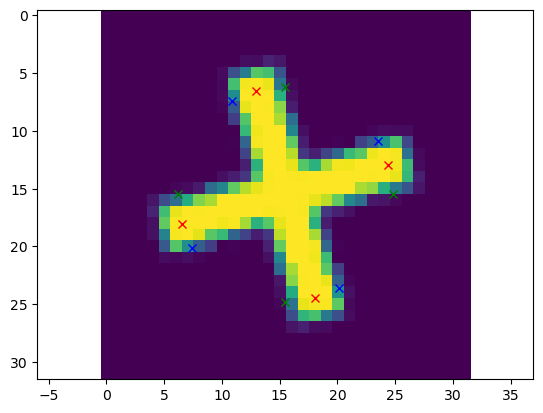

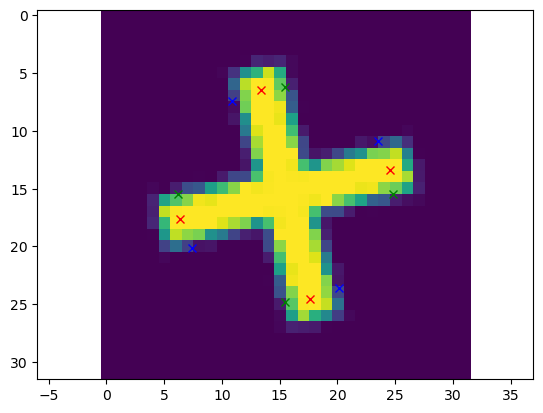

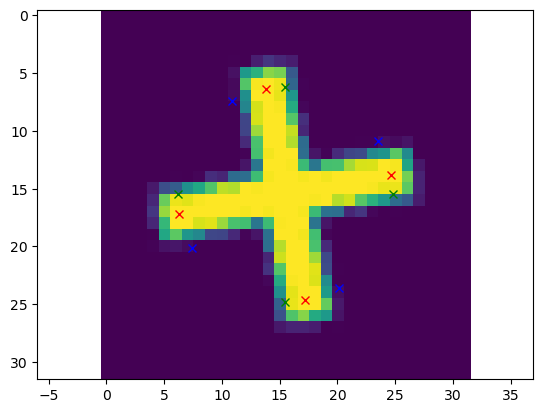

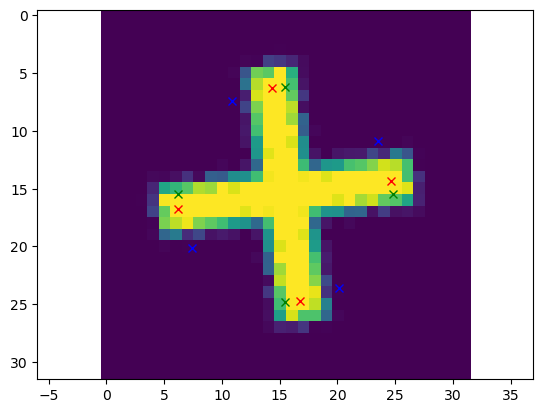

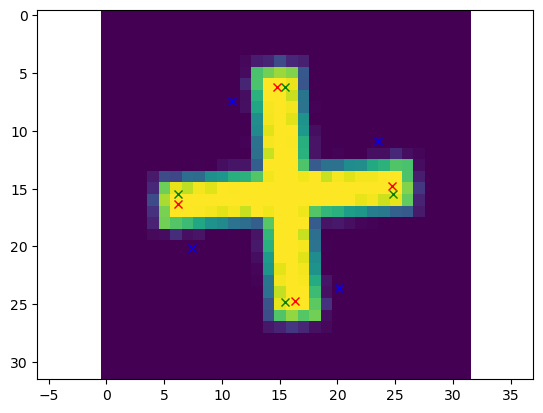

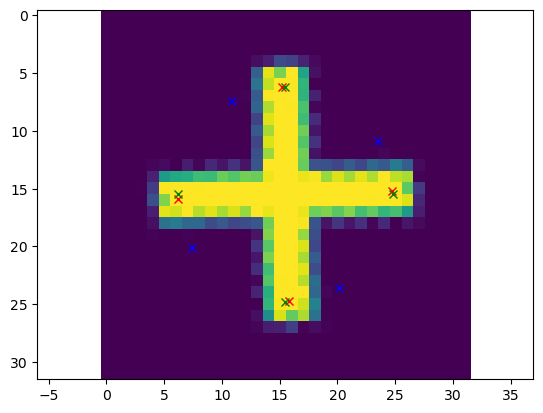

In [43]:
for state in intermediates['states']:
    plt.figure()
    pts = state.gd[0]
    deformed_image_i = source_deformable._to_deformed(
                state.manifolds[1].gd)
    plt.imshow(deformed_image_i[0])
    plt.plot(pts[:,0].detach(), pts[:,1].detach(), 'xr')
    plt.plot(source_dots.numpy()[:, 0], source_dots.numpy()[:, 1], 'xb')
    plt.plot(target_dots.numpy()[:, 0], target_dots.numpy()[:, 1], 'xg')
    plt.axis('equal')